# Interacting with prop datasets

To know
- Distribution of lengths -> compute cut-offs
- Distribution of splits -> compute splits

In [1]:
from multiprocessing import Pool

import datasets
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm

from prop import *

In [14]:
# ds_path = full_text_ds_path
ds_path = '/n/home09/wlt/scratch/data/prop_gen/data/hf_or_big_text'
ds = datasets.load_from_disk(ds_path)
ds

DatasetDict({
    True_3: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 940416
    })
    False_3: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 12
    })
    True_4: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 940546
    })
    True_5: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 1037004
    })
    False_5: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 48
    })
    True_6: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 934543
    })
    True_7: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_rows: 894638
    })
    False_7: Dataset({
        features: ['is_true', 'completion', 'length', 'ops', 'prompt'],
        num_ro

In [15]:
ds.cleanup_cache_files()

{'True_3': 0,
 'False_3': 0,
 'True_4': 0,
 'True_5': 0,
 'False_5': 0,
 'True_6': 0,
 'True_7': 0,
 'False_7': 0,
 'True_8': 0,
 'True_9': 0,
 'False_9': 0,
 'True_10': 0,
 'True_11': 0,
 'False_11': 0,
 'True_12': 0,
 'True_13': 0,
 'False_13': 0,
 'True_14': 0,
 'True_15': 0,
 'False_15': 0,
 'True_16': 0,
 'False_1': 0,
 'True_2': 0}

Text(0, 0.5, 'number of examples')

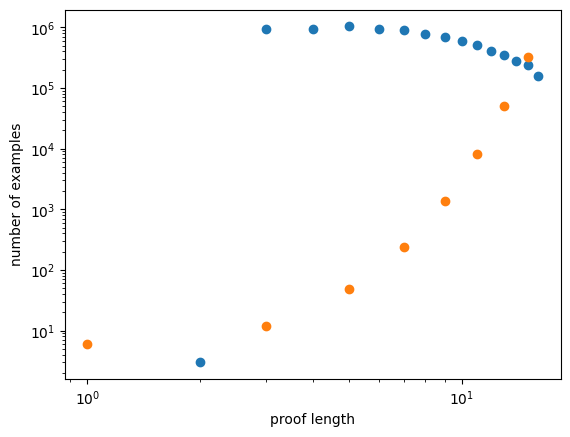

In [16]:
t_vals = []
f_vals = []

for k, v in ds.items():
    name, num = k.split('_')

    if name == 'True':
        t_vals.append((int(num), len(v)))
    else:
        f_vals.append((int(num), len(v)))
        
# <codecell>
import matplotlib.pyplot as plt

t_idx, t_lens = np.array(t_vals).T
f_idx, f_lens = np.array(f_vals).T
plt.scatter(t_idx, t_lens)
plt.scatter(f_idx, f_lens)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('proof length')
plt.ylabel('number of examples')

prop | t_idx | f_idx
----------------------
 0.2:     3     13
 0.4:     5     13
 0.5:     6     13
 0.6:     7     13
 0.8:    10     13
0.95:    13     13


Text(0, 0.5, 'cumulative proportion of examples')

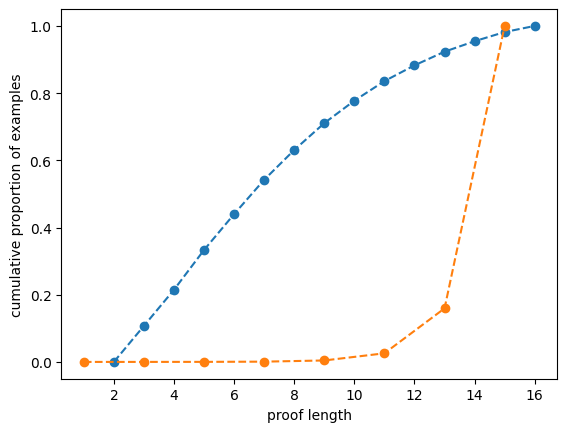

In [17]:
t_sort_idx = np.argsort(t_idx)
t_cum = np.cumsum(t_lens[t_sort_idx]) / np.sum(t_lens)

f_sort_idx = np.argsort(f_idx)
f_cum = np.cumsum(f_lens[f_sort_idx]) / np.sum(f_lens)

plt.plot(np.sort(t_idx), t_cum, 'o--')
plt.plot(np.sort(f_idx), f_cum, 'o--')

props = [0.2, 0.4, 0.5, 0.6, 0.8, 0.95]

t_idxs = []
f_idxs = []
for p in props:
    idx = np.sum(t_cum < p) - 1
    t_idxs.append(t_idx[t_sort_idx][idx].item())
    
    idx = np.sum(f_cum < p) - 1
    f_idxs.append(f_idx[f_sort_idx][idx].item())

print(f'prop | t_idx | f_idx')
print('----------------------')
for prop, t, f in zip(props, t_idxs, f_idxs):
    print(f'{prop:4}: {t:5} {f:6}')

plt.xlabel('proof length')
plt.ylabel('cumulative proportion of examples')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-Coder-7B')

def to_toks(ex):
    inp_and_proof_toks = tokenizer(ex['prompt'] + ex['completion'], return_attention_mask=False)

    return {
        'tok_len': len(inp_and_proof_toks['input_ids']),
    }

ds = ds.map(to_toks, batched=False, num_proc=16)

In [ ]:
def get_len(ex):
    return ex['tok_len']

all_lens = []
for name, sub_ds in ds.items():
    print(f'info: parsing {name}')
    with Pool(16) as pool:
        lens = pool.map(get_len, sub_ds)
    all_lens.extend(lens)


In [ ]:
plt.hist(all_lens, bins=50)
np.quantile(all_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

In [ ]:
max(all_lens)

In [ ]:
example = ds['False_497'][0]
out = tokenizer(example['prompt'] + example['completion'], return_attention_mask=False)
len(out['input_ids'])

## Length distributions for different datasets

Full
```
prop | t_idx | f_idx
----------------------
 0.2:     2      1
 0.4:     3      4
 0.5:     4      4
 0.6:     5      5
 0.8:     7      8
0.95:    11     14
```

Imply
```
prop | t_idx | f_idx
----------------------
 0.2:     2     11
 0.4:     3     14
 0.5:     3     17
 0.6:     3     20
 0.8:     5     28
0.95:    12     56
```


Or
```
prop | t_idx | f_idx
----------------------
 0.2:     3     13
 0.4:     5     13
 0.5:     6     13
 0.6:     7     13
 0.8:    10     13
0.95:    13     13
```

PHP
```
prop | t_idx | f_idx
----------------------
 0.2:    15     55
 0.4:    36     55
 0.5:    42     71
 0.6:    42     71
 0.8:    80     92
0.95:   143    104
```